# FRT

## Data

In [ ]:
from vnstock import *
import pandas as pd
import time
import matplotlib.pyplot as plt

In [2]:
stock = Vnstock().stock(symbol='CMV', source='VCI')

In [24]:
frt = stock.quote.history(symbol='FRT', start='2025-04-07', end='2025-04-17', interval='1D')

In [32]:
vnindex = stock.quote.history(symbol='VNINDEX', start='2025-04-07', end='2025-04-17', interval='1D')

In [31]:
frt

,time,open,high,low,close,volume
0,2025-04-08,135.0,136.0,130.2,130.2,821700
1,2025-04-09,121.1,131.0,121.1,124.1,1144300
2,2025-04-10,132.7,132.7,132.7,132.7,54500
3,2025-04-11,141.9,141.9,137.9,141.9,726700
4,2025-04-14,149.9,151.5,145.0,151.0,817500
5,2025-04-15,150.0,151.0,147.9,148.5,412300
6,2025-04-16,148.5,150.9,141.7,145.0,442500
7,2025-04-17,143.0,145.9,141.0,143.0,131800


In [33]:
vnindex

,time,open,high,low,close,volume
0,2025-04-08,1210.67,1210.67,1130.98,1132.79,1142648348
1,2025-04-09,1112.27,1141.35,1073.61,1094.30,1593990576
2,2025-04-10,1094.30,1168.40,1094.30,1168.34,367335058
3,2025-04-11,1185.86,1222.46,1180.59,1222.46,1720215979
4,2025-04-14,1235.01,1242.94,1226.06,1241.44,1037578710
5,2025-04-15,1241.44,1246.21,1221.75,1227.79,1064439792
6,2025-04-16,1227.79,1233.84,1205.93,1210.30,816347824
7,2025-04-17,1210.30,1217.25,1197.50,1217.25,756538553


In [34]:
vnindex.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   time    8 non-null      datetime64[ns]
 1   open    8 non-null      float64       
 2   high    8 non-null      float64       
 3   low     8 non-null      float64       
 4   close   8 non-null      float64       
 5   volume  8 non-null      int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 516.0 bytes


In [30]:
frt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   time    8 non-null      datetime64[ns]
 1   open    8 non-null      float64       
 2   high    8 non-null      float64       
 3   low     8 non-null      float64       
 4   close   8 non-null      float64       
 5   volume  8 non-null      int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 516.0 bytes


In [35]:
frt.to_csv('FRT_7-4-2025.csv')
vnindex.to_csv('VNINDEX_7-4-2025.csv')

## Phân tích biến động

In [36]:
def growth_index_per_day(close):
    if close.empty:
        return pd.Series()
    return (close - close.iloc[0]) * 100 / close.iloc[0] 

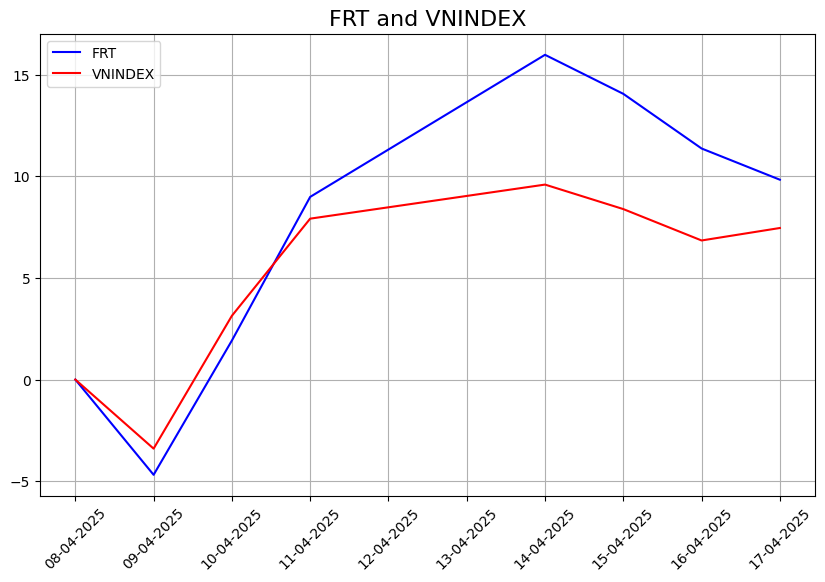

In [44]:
from matplotlib import dates

time_stock = frt['time']
value_stock = frt['close']

time_vnindex = vnindex['time']
value_vnindex = vnindex['close']

plt.figure(figsize=(10, 6))
plt.plot(time_stock, growth_index_per_day(value_stock), color='blue', label="FRT")
plt.plot(time_vnindex, growth_index_per_day(value_vnindex), color='red', label="VNINDEX")

plt.gca().xaxis.set_major_formatter(dates.DateFormatter('%d-%m-%Y'))
plt.gca().xaxis.set_major_locator(dates.DayLocator(interval=1))  # Hiển thị cách ngày 1 ngày

plt.xticks(rotation=45)  # Xoay nhãn ngày

plt.grid(True)
plt.legend(loc='upper left') 

plt.title("FRT and VNINDEX", fontsize=16)

plt.show()

In [45]:
frt['symbol'] = 'FRT'
vnindex['symbol'] = 'VNINDEX'
all_data = pd.concat([frt, vnindex], ignore_index=True)
all_data

,time,open,high,low,close,volume,symbol
0,2025-04-08,135.00,136.00,130.20,130.20,821700,FRT
1,2025-04-09,121.10,131.00,121.10,124.10,1144300,FRT
2,2025-04-10,132.70,132.70,132.70,132.70,54500,FRT
3,2025-04-11,141.90,141.90,137.90,141.90,726700,FRT
4,2025-04-14,149.90,151.50,145.00,151.00,817500,FRT
5,2025-04-15,150.00,151.00,147.90,148.50,412300,FRT
6,2025-04-16,148.50,150.90,141.70,145.00,442500,FRT
7,2025-04-17,143.00,145.90,141.00,143.00,131800,FRT
8,2025-04-08,1210.67,1210.67,1130.98,1132.79,1142648348,VNINDEX
9,2025-04-09,1112.27,1141.35,1073.61,1094.30,1593990576,VNINDEX


In [46]:
all_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   time    16 non-null     datetime64[ns]
 1   open    16 non-null     float64       
 2   high    16 non-null     float64       
 3   low     16 non-null     float64       
 4   close   16 non-null     float64       
 5   volume  16 non-null     int64         
 6   symbol  16 non-null     object        
dtypes: datetime64[ns](1), float64(4), int64(1), object(1)
memory usage: 1.0+ KB


In [55]:
# Tính % thay đổi
all_data['change'] = all_data.groupby('symbol')['close'].pct_change() * 100

# Tóm tắt biến động
summary = all_data.groupby('symbol').agg(
    start_price=('close', lambda x: x.iloc[0]),
    end_price=('close', lambda x: x.iloc[-1]),
    total_change_percent=('close', lambda x: ((x.iloc[-1] / x.iloc[0] - 1) * 100).round(2))
)

print("Tổng quan biến động từ 07-04-2025 đến nay:")
summary = pd.DataFrame(summary)
summary

Tổng quan biến động từ 07-04-2025 đến nay:


,start_price,end_price,total_change_percent
symbol,,,
FRT,130.20,143.00,9.83
VNINDEX,1132.79,1217.25,7.46


In [65]:
# Lấy volume
volume = all_data.groupby('symbol')['volume'].sum()
# Tạo DataFrame
df_volume = pd.DataFrame(volume)
df_volume = df_volume.reset_index()
# Tính phần trăm
df_volume['percent'] = df_volume['volume'] / df_volume['volume'].sum() * 100
df_volume['label'] = df_volume['symbol'] + ', ' + df_volume['percent'].round(1).astype(str) + '%'

In [66]:
df_volume

,symbol,volume,percent,label
0,FRT,4551300,0.053522,"FRT, 0.1%"
1,VNINDEX,8499094840,99.946478,"VNINDEX, 99.9%"


The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.


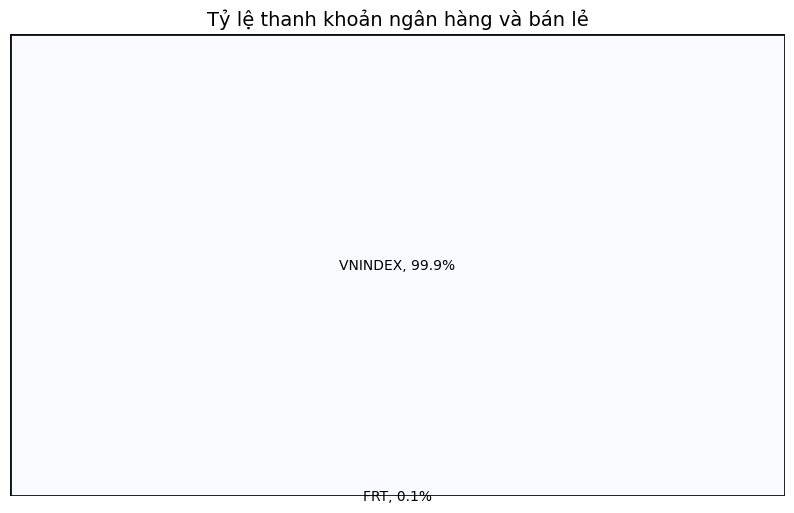

In [68]:
import matplotlib.pyplot as plt
import squarify
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# Tạo hai DataFrame: bank và retail
df_frt = df_volume[df_volume['symbol'] == 'FRT']
df_vnindex = df_volume[df_volume['symbol'] == 'VNINDEX']

# Normalize theo từng nhóm
norm_vnindex = mcolors.Normalize(vmin=df_vnindex['percent'].min() , vmax=df_vnindex['percent'].max())
norm_frt = mcolors.Normalize(vmin=df_frt['percent'].min(), vmax=df_frt['percent'].max())

# Colormap cho từng nhóm
cmap_vnindex = cm.get_cmap('Oranges')    # Bank: cam - đỏ
cmap_frt = cm.get_cmap('Blues')  # Retail: xanh biển - tím

# Tạo danh sách màu
colors = []
for _, row in df_volume.iterrows():
    if row['symbol'] == '':
        color = cmap_vnindex(norm_vnindex(row['percent']))
    else:
        color = cmap_frt(norm_frt(row['percent']))
    colors.append(color)

# Vẽ treemap
plt.figure(figsize=(10, 6))
squarify.plot(
    sizes=df_volume['volume'],
    label=df_volume['label'],
    color=colors,
    alpha=0.95,
    edgecolor='black',  # viền trắng phân biệt rõ
    linewidth=2
)

plt.title('Tỷ lệ thanh khoản ngân hàng và bán lẻ', fontsize=14)
plt.axis('off')
plt.show()

# Data yfinance - Có sự khác biệt giữa 2 data cần kiểm tra

In [27]:
import yfinance as yf
right_column_names = ['close', 'high', 'low', 'open', 'volume']
data = yf.download('FRT', start="2025-04-07", end="2025-04-17", interval='1d')
data.columns = right_column_names
data['symbol'] = 'FRT'

[*********************100%***********************]  1 of 1 completed


In [28]:
data

,close,high,low,open,volume,symbol
Date,,,,,,
2025-04-07,86.570000,89.919998,84.559998,86.519997,1450300,FRT
2025-04-08,83.559998,89.849998,82.629997,89.500000,1853400,FRT
2025-04-09,90.379997,91.010002,80.650002,82.230003,1783600,FRT
2025-04-10,88.959999,91.419998,86.650002,89.120003,1212500,FRT
2025-04-11,90.260002,91.139999,87.190002,89.510002,949400,FRT
2025-04-14,92.279999,92.860001,91.029999,91.029999,1094600,FRT
2025-04-15,92.300003,93.300003,91.989998,92.279999,733600,FRT
2025-04-16,92.070000,93.400002,91.330002,92.300003,636600,FRT


In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 8 entries, 2025-04-07 to 2025-04-16
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   close   8 non-null      float64
 1   high    8 non-null      float64
 2   low     8 non-null      float64
 3   open    8 non-null      float64
 4   volume  8 non-null      int64  
 5   symbol  8 non-null      object 
dtypes: float64(4), int64(1), object(1)
memory usage: 448.0+ bytes


# Đầu tư công

## Sàn HSX - HOSE

In [3]:
hsx_symbols = ['C47', 'HTN', 'CII', 'CTD', 'CTI', 'CTR', 'DPG', 'EVG', 'FCN', 'HUB', 'HBC', 'HHV', 'LCG', 'VCG']

In [7]:
vnindex = stock.quote.history(symbol='VNINDEX', start='2025-04-01', end='2025-04-23', interval='1D')

In [8]:
df_total = pd.DataFrame()

for symbol in hsx_symbols:
    try:
        df = stock.quote.history(symbol=symbol, start='2025-04-01', end='2025-04-23', interval='1D')
        df['symbol'] = symbol
        df_total = pd.concat([df_total, df], ignore_index=True)
    except ValueError as e:
        print(f"Error for symbol {symbol}: {e}")
    except Exception as e:

        print(f"Unexpected error for symbol {symbol}: {e}")
    time.sleep(1)

In [11]:
vnindex.to_csv('VINDEX_T4.csv', index=False)

In [9]:
df_total.to_csv('Dau_tu_cong_hsx.csv', index=False)

## Sàn HNX

In [4]:
hnx_symbols = ['VC9', 'MST', 'PDB', 'S99', 'SCI', 'HUT']

In [10]:
hnxindex = stock.quote.history(symbol='HNXINDEX', start='2025-04-01', end='2025-04-23', interval='1D')

In [15]:
df_total = pd.DataFrame()

for symbol in hnx_symbols:
    try:
        df = stock.quote.history(symbol=symbol, start='2025-04-01', end='2025-04-23', interval='1D')
        df['symbol'] = symbol
        df_total = pd.concat([df_total, df], ignore_index=True)
    except ValueError as e:
        print(f"Error for symbol {symbol}: {e}")
    except Exception as e:

        print(f"Unexpected error for symbol {symbol}: {e}")
    time.sleep(1)

In [13]:
hnxindex.to_csv('HNXINDEX_T4.csv', index=False)

In [16]:
df_total.to_csv('Dau_tu_cong_hnx.csv', index=False)

## Sàn UPCOM

In [5]:
upcom_symbols = ['G36', 'C4G']

In [18]:
upcomindex = stock.quote.history(symbol='UPCOMINDEX', start='2025-04-01', end='2025-04-23', interval='1D')

In [19]:
df_total = pd.DataFrame()

for symbol in upcom_symbols:
    try:
        df = stock.quote.history(symbol=symbol, start='2025-04-01', end='2025-04-23', interval='1D')
        df['symbol'] = symbol
        df_total = pd.concat([df_total, df], ignore_index=True)
    except ValueError as e:
        print(f"Error for symbol {symbol}: {e}")
    except Exception as e:

        print(f"Unexpected error for symbol {symbol}: {e}")
    time.sleep(1)

In [20]:
upcomindex.to_csv('UPCOMINDEX_T4.csv', index=False)

In [21]:
df_total.to_csv('Dau_tu_cong_upcom.csv', index=False)

## Phân tích biến động

### Chỉ số tăng Index

In [2]:
hnx = pd.read_csv('BT4/Dau_tu_cong_hnx.csv')
hsx = pd.read_csv('BT4/Dau_tu_cong_hsx.csv')
upcom = pd.read_csv('BT4/Dau_tu_cong_upcom.csv')

In [3]:
hnx['time'] = pd.to_datetime(hnx['time'])
hsx['time'] = pd.to_datetime(hsx['time'])
upcom['time'] = pd.to_datetime(upcom['time'])

In [41]:
def growth_index(df):
    close_last = df.loc[df['time'].idxmax(), 'close']
    close_first = df.loc[df['time'].idxmin(), 'close']
    growth_value = (close_last - close_first) * 100 / close_first
    return growth_value

In [50]:
def precompute(stock, sto_ex, name_exchange):
    exchange_index_item = {}
    exchange_index_item['symbol'] = name_exchange
    exchange_index_item['value'] = growth_index(sto_ex)

    # symbol_stocks = []
    # for symbol in stock['symbol'].unique():
    #     item = {}
    #     item['symbol'] = symbol
    #     df_symbol = stock[(stock['symbol'] == symbol)]
    #     item['value'] = growth_index(df_symbol)
    #     symbol_stocks.append(item)
    
    symbol_stocks = []
    for symbol in stock['symbol'].unique():
        item = {
            'symbol': symbol,
            'value': growth_index(stock[stock['symbol'] == symbol])
        }
        symbol_stocks.append(item)
    
    return exchange_index_item, symbol_stocks

In [75]:
def visualize_overall_growth(dictionary, list_dict, name_exchange):
    index_value = dictionary['value']

    symbols = [symbol_stock['symbol'] for symbol_stock in list_dict]
    values = [symbol_stock['value'] for symbol_stock in list_dict]

    plt.figure(figsize=(12, 6))
    plt.bar(symbols, values, color='skyblue', edgecolor='black')

    plt.axhline(y=index_value, color="red", linestyle="--", linewidth=3, label=f"{name_exchange}: {index_value:.2f}")

    plt.xticks(rotation=90)
    plt.ylabel("Index Value")
    plt.title(f"{name_exchange}")
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    plt.show()

In [23]:
def growth_index_per_day(close):
    if close.empty:
        return pd.Series()
    return (close - close.iloc[0]) * 100 / close.iloc[0] 

In [ ]:
# visualize all plot into 1 plot
import matplotlib.pyplot as plt
from matplotlib import dates
import math

def visualize_all_stock(stock, symbols, sto_ex, name_exchange):
    n = len(symbols)
    cols = 3  # số biểu đồ mỗi hàng
    rows = math.ceil(n / cols)

    fig, axs = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows), constrained_layout=True)
    axs = axs.flatten()  # chuyển về 1D array để dễ truy cập

    for i, symbol in enumerate(symbols):
        ax = axs[i]
        time_stock = stock[stock['symbol'] == symbol]['time']
        value_stock = stock[stock['symbol'] == symbol]['close']

        time_exchange = sto_ex['time']
        value_exchange = sto_ex['close']

        ax.plot(time_stock, growth_index_per_day(value_stock), color='blue', label=f"{symbol}")
        ax.plot(time_exchange, growth_index_per_day(value_exchange), color='red', label=name_exchange)

        ax.xaxis.set_major_formatter(dates.DateFormatter('%d-%m-%Y'))
        ax.xaxis.set_major_locator(dates.DayLocator(interval=3)) 
        
        # Xoay nhãn ngày
        for label in ax.get_xticklabels():
            label.set_rotation(45)  
            
        ax.set_title(f"{symbol} vs {name_exchange}", fontsize=10)
        ax.legend(loc='upper left')
        ax.grid(True)
    
    # Xóa subplot trống (nếu có)
    for j in range(i+1, len(axs)):
        fig.delaxes(axs[j])

    plt.tight_layout()
    plt.show()

In [66]:
# visualize each plot
from matplotlib import dates

def show_plt(stock, symbol, sto_ex, name_exchange):
  time_stock = stock[stock['symbol'] == symbol]['time']
  value_stock = stock[stock['symbol'] == symbol]['close']

  time_exchange = sto_ex['time']
  value_exchange = sto_ex['close']
  
  plt.figure(figsize=(10, 6))
  plt.plot(time_stock, growth_index_per_day(value_stock), color='blue', label=f"{symbol}")
  plt.plot(time_exchange, growth_index_per_day(value_exchange), color='red', label=name_exchange)

  plt.gca().xaxis.set_major_formatter(dates.DateFormatter('%d-%m-%Y'))
  plt.gca().xaxis.set_major_locator(dates.DayLocator(interval=1))
  plt.gcf().autofmt_xdate()

  plt.grid(True)
  plt.legend(loc='upper left') 
#   # Cố định scale trục tung
#   plt.ylim(-150, 1500)  # Điều chỉnh tùy theo độ biến động bạn muốn theo dõi

  plt.title(f"{symbol} and {name_exchange}", fontsize=16)

  plt.show()

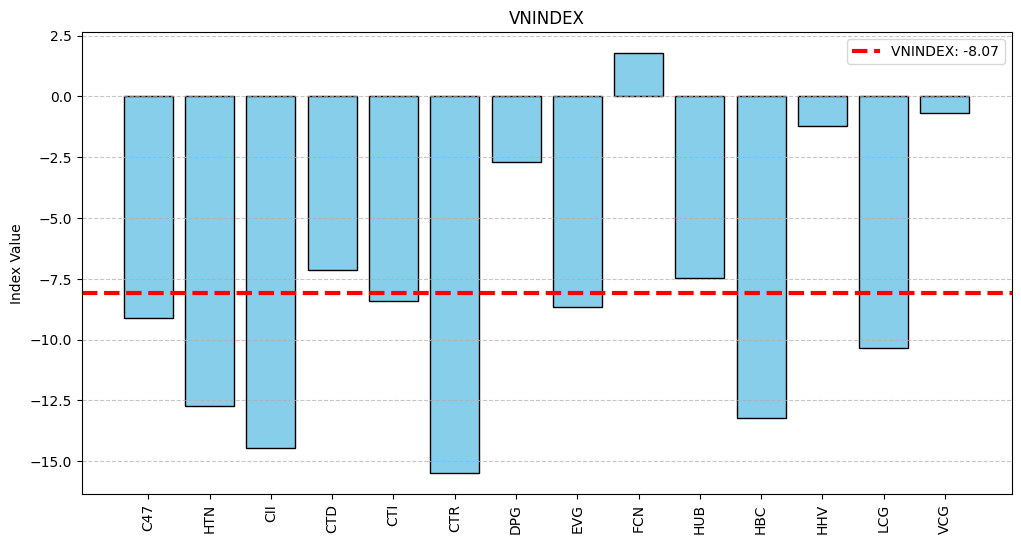

In [76]:
# Overall HSX Exchange
vnindex_dict, hsx_list = precompute(hsx, vnindex, "VNINDEX")
visualize_overall_growth(vnindex_dict, hsx_list, "VNINDEX")

The figure layout has changed to tight


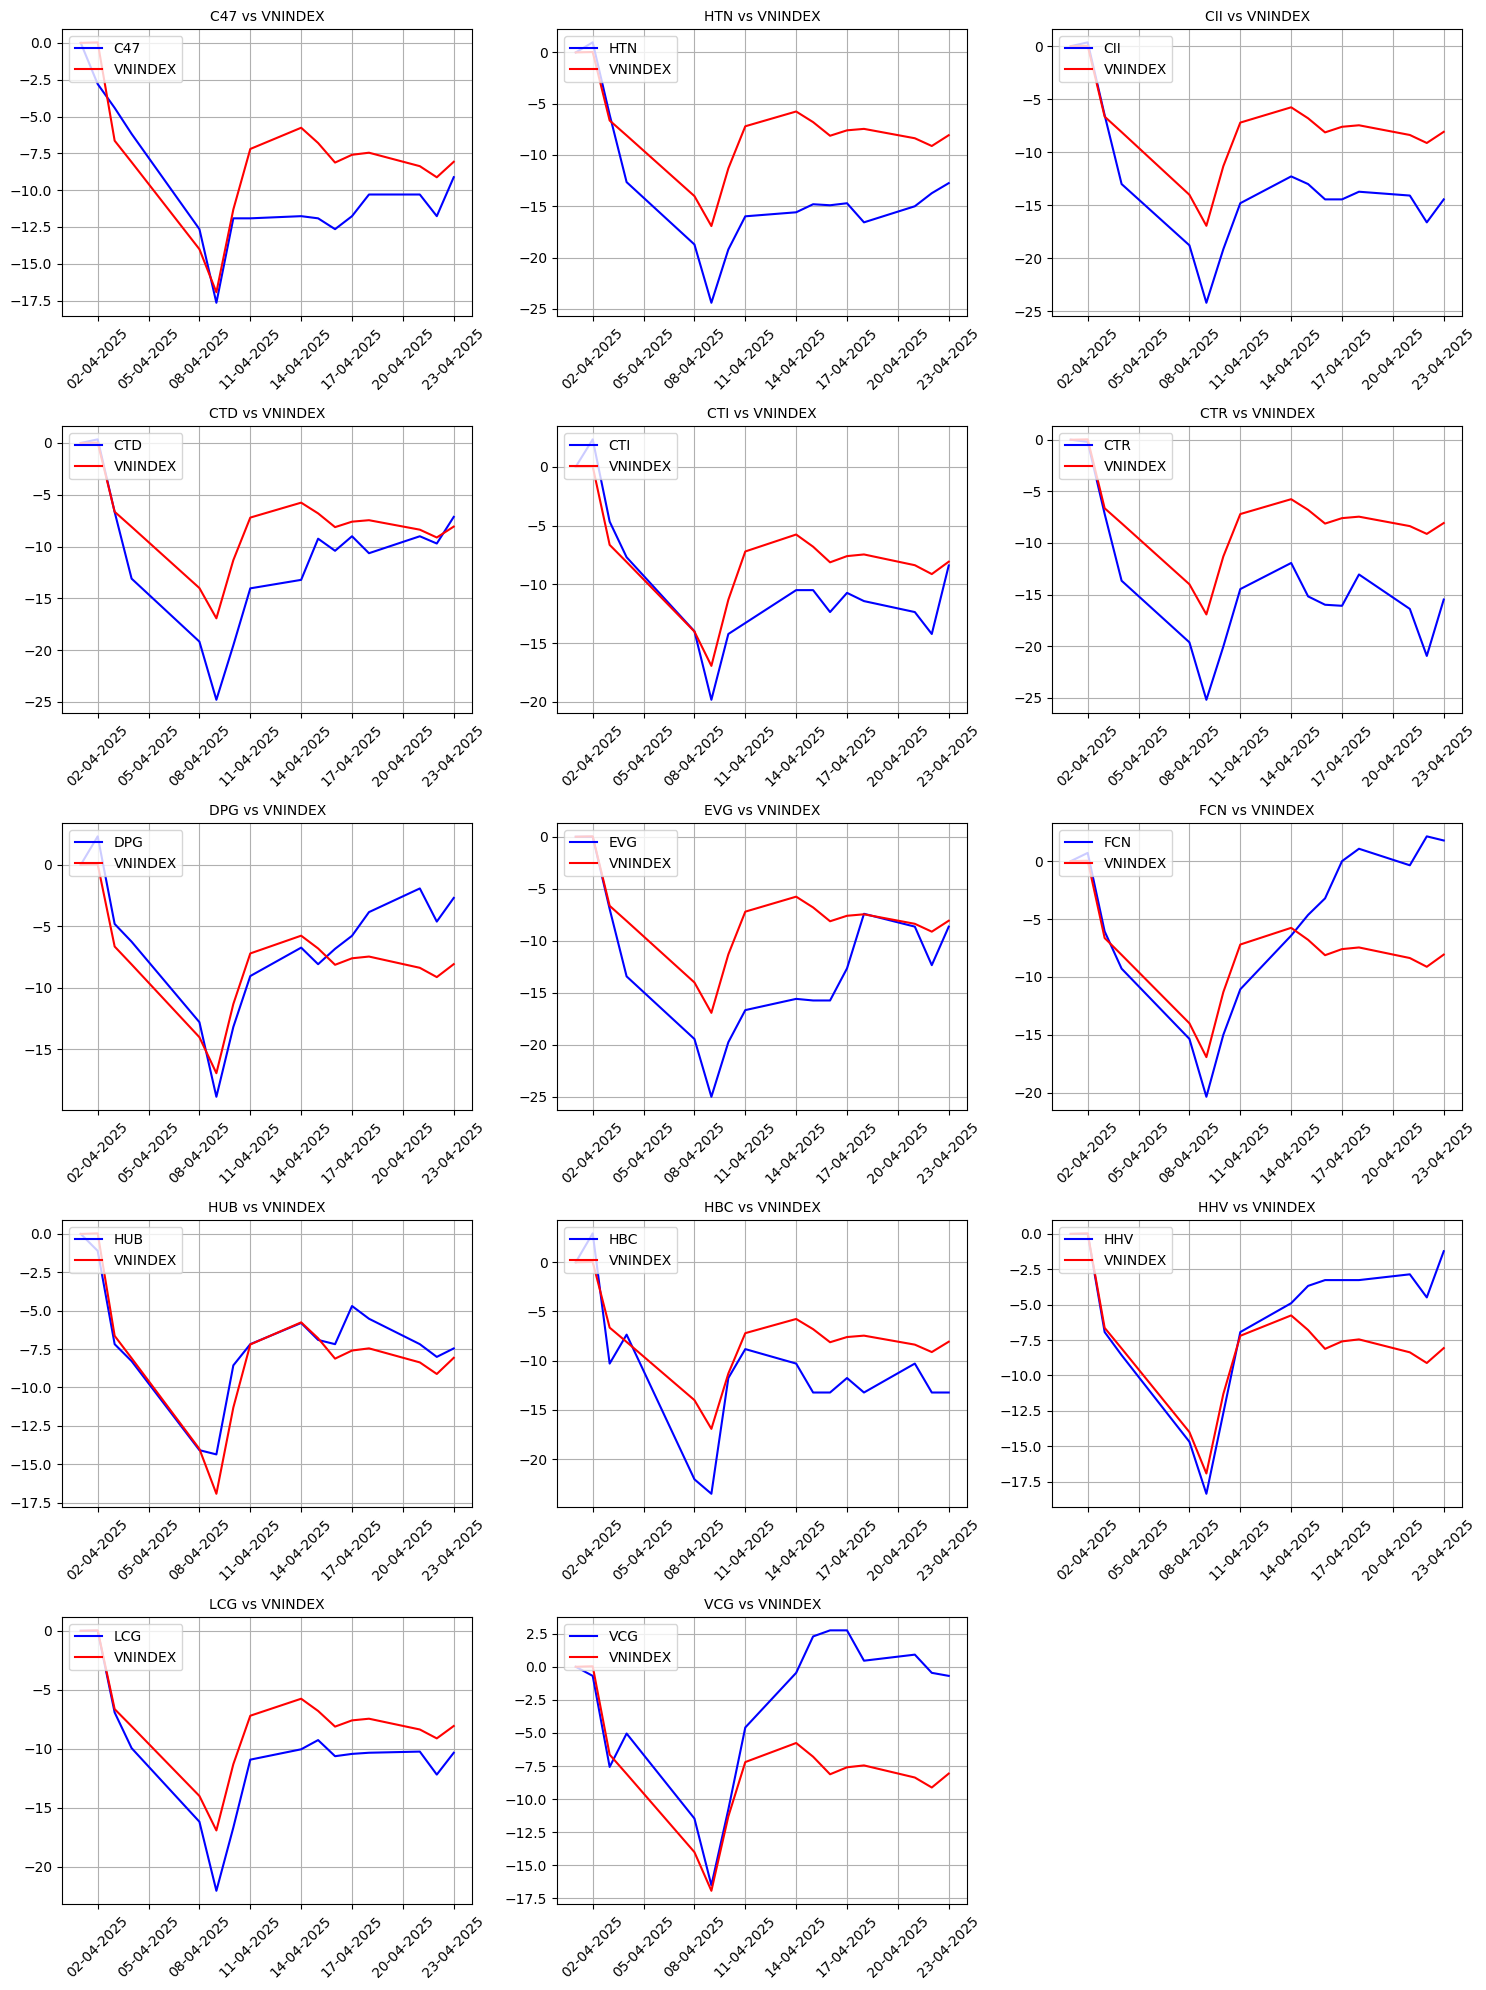

In [ ]:
# Details HSX Stock Exchange

# for symbol in hsx['symbol'].unique():
#   show_plt(hsx, symbol, vnindex, 'VNINDEX')

visualize_all_stock(hsx, hsx['symbol'].unique(), vnindex, 'VNINDEX')

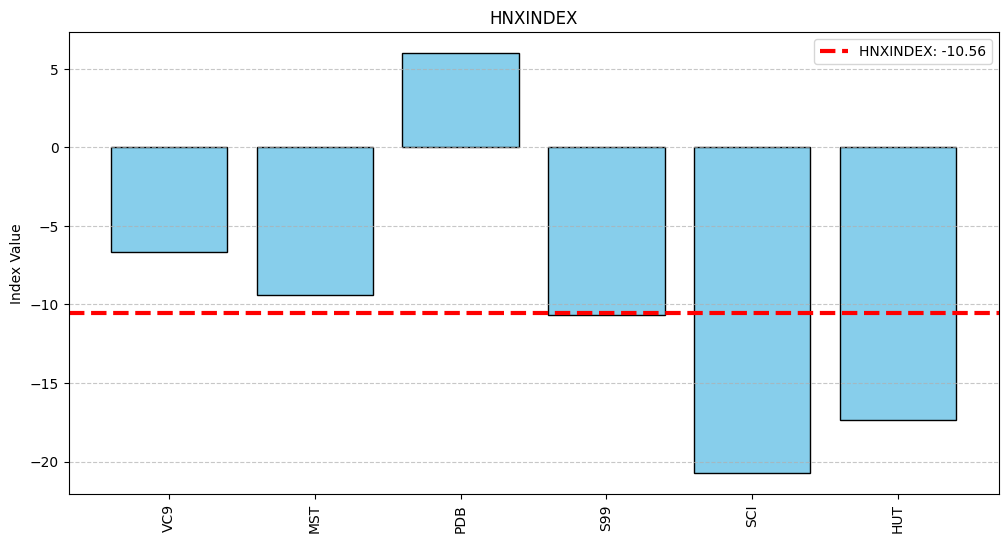

In [77]:
# Overall HNX Exchange Stock
hnxindex_dict, hnx_list = precompute(hnx, hnxindex, "HNXINDEX")
visualize_overall_growth(hnxindex_dict, hnx_list, "HNXINDEX")

The figure layout has changed to tight


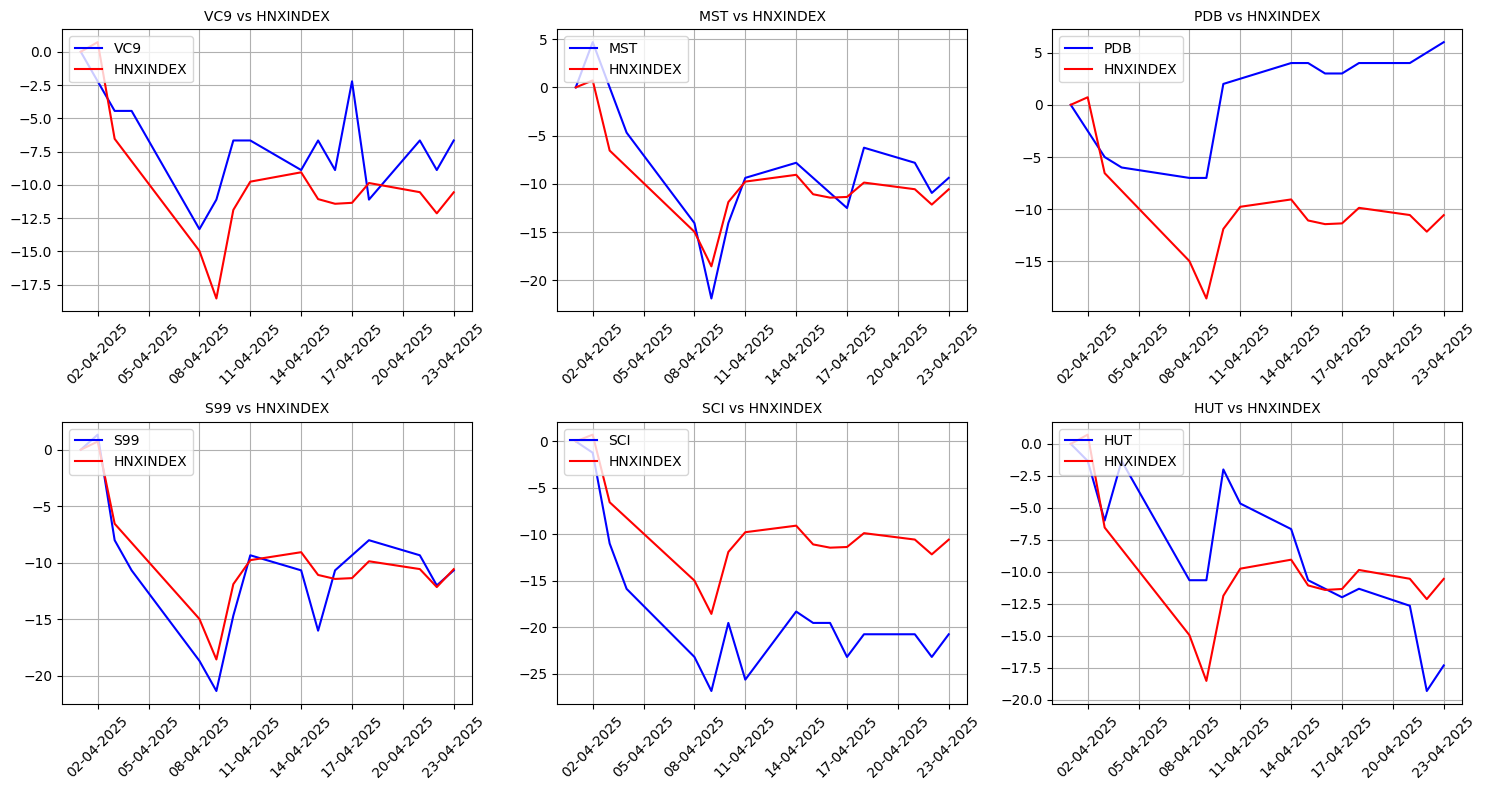

In [67]:
# Details HNX Exchange Stock
visualize_all_stock(hnx, hnx['symbol'].unique(), hnxindex, 'HNXINDEX')

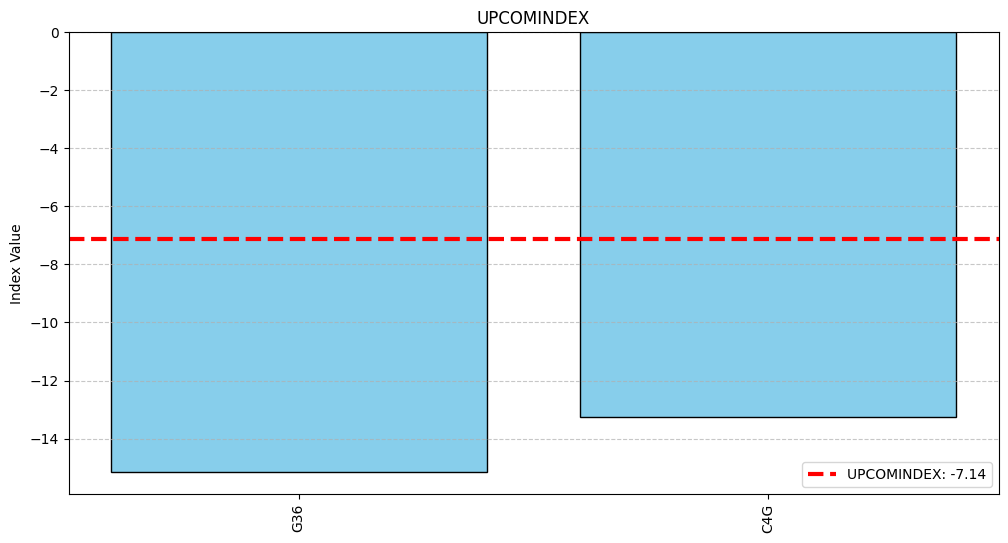

In [78]:
# Overall UPCOM Exchange Stock
upcomindex_dict, upcom_list = precompute(upcom, upcomindex, "UPCOMINDEX")
visualize_overall_growth(upcomindex_dict, upcom_list, "UPCOMINDEX")

The figure layout has changed to tight


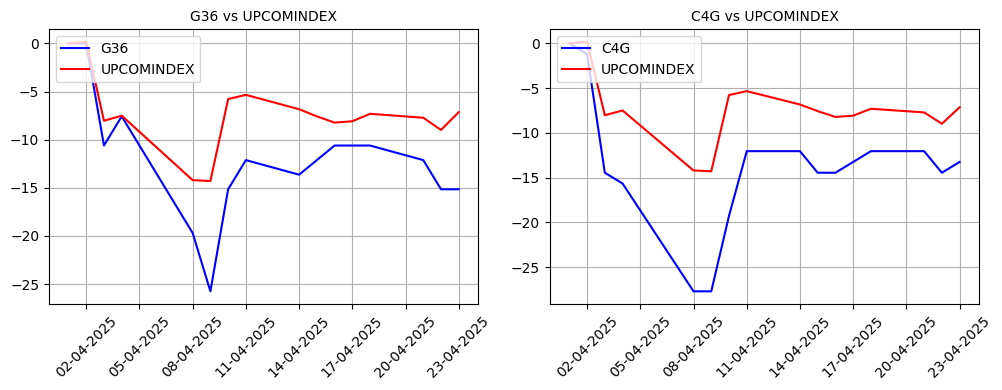

In [69]:
# Detail UPCOM Exchange Stock
visualize_all_stock(upcom, upcom['symbol'].unique(), upcomindex, 'UPCOMINDEX')

### Thanh khoản

In [8]:
# create merge dataframe
merge = pd.DataFrame()
merge_list = [hsx, hnx, upcom]
for df in merge_list:
    merge = pd.concat([merge, df], ignore_index=True)
    
# Lấy volume
volume = merge.groupby('symbol')['volume'].sum()

# Tạo volume dataFrame
df_volume = pd.DataFrame(volume)
df_volume = df_volume.reset_index()

# Tính phần trăm
df_volume['percent'] = df_volume['volume'] / df_volume['volume'].sum() * 100
df_volume['label'] = df_volume['symbol'] + ', ' + df_volume['percent'].round(3).astype(str) + '%'

In [9]:
df_volume

,symbol,volume,percent,label
0,C47,620000,0.077322,"C47, 0.077%"
1,C4G,17828600,2.223464,"C4G, 2.223%"
2,CII,162172500,20.225073,"CII, 20.225%"
3,CTD,25903000,3.230449,"CTD, 3.23%"
4,CTI,20902100,2.606771,"CTI, 2.607%"
5,CTR,12034000,1.500800,"CTR, 1.501%"
6,DPG,13425900,1.674389,"DPG, 1.674%"
7,EVG,22276700,2.778201,"EVG, 2.778%"
8,FCN,21274400,2.653201,"FCN, 2.653%"
9,G36,3733400,0.465605,"G36, 0.466%"


In [10]:
df_volume.to_csv('thanh_khoan.csv', index=False)

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.


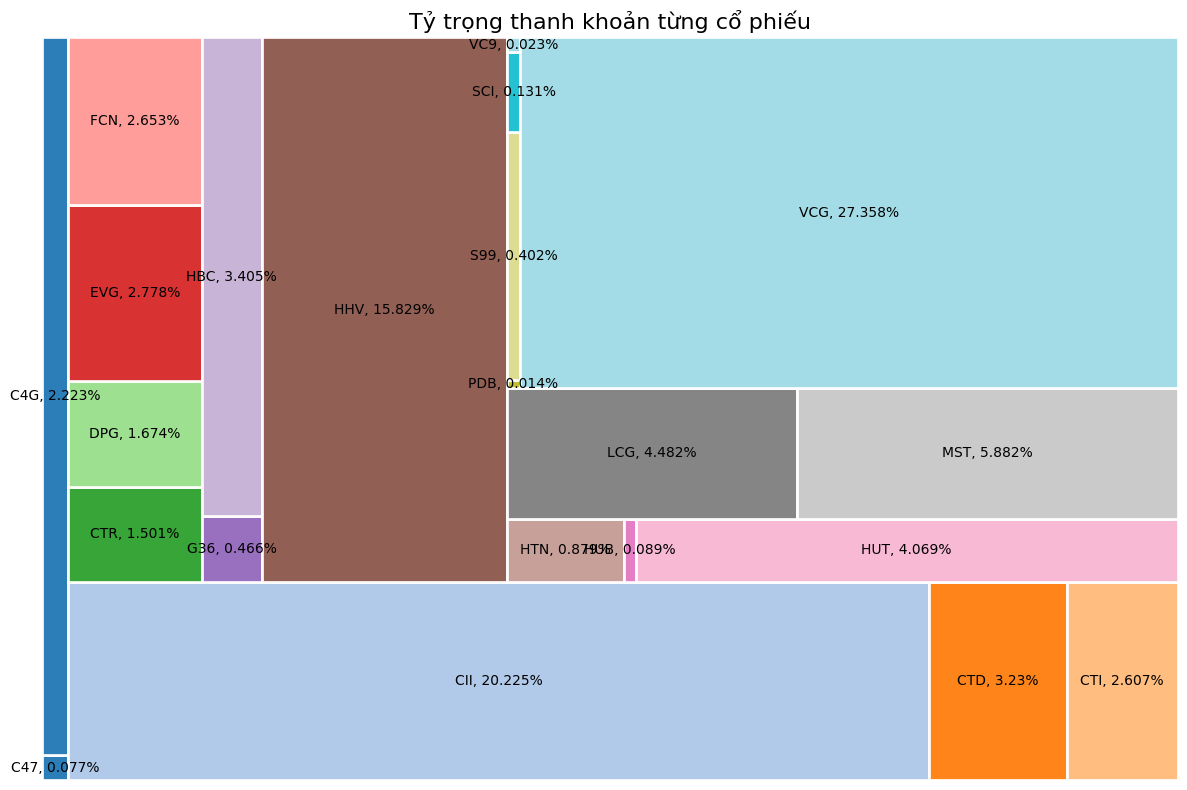

In [11]:
# visualize tree map stock volume
import matplotlib.pyplot as plt
import squarify
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# Sử dụng colormap để sinh màu tự động (ví dụ: 'tab20' có 20 màu phân biệt)
cmap = cm.get_cmap('tab20', len(df_volume))

# Tạo danh sách màu riêng cho từng cổ phiếu
colors = [mcolors.rgb2hex(cmap(i)) for i in range(len(df_volume))]

# Vẽ treemap
plt.figure(figsize=(12, 8))
squarify.plot(
    sizes=df_volume['volume'],
    label=df_volume['label'],
    color=colors,
    alpha=0.95,
    edgecolor='white',
    linewidth=2
)

plt.title('Tỷ trọng thanh khoản từng cổ phiếu', fontsize=16)
plt.axis('off')
plt.tight_layout()
plt.show()


### Tiềm năng

In [80]:
pc1 = stock.quote.history(symbol='PC1', start='2025-04-01', end='2025-04-23', interval='1D')

In [82]:
pc1['symbol'] = 'PC1'
pc1['time'] = pd.to_datetime(pc1['time'])

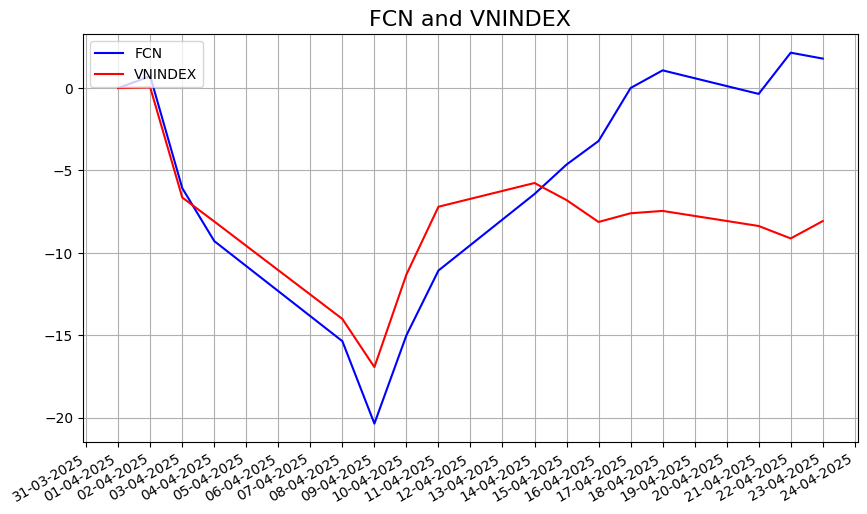

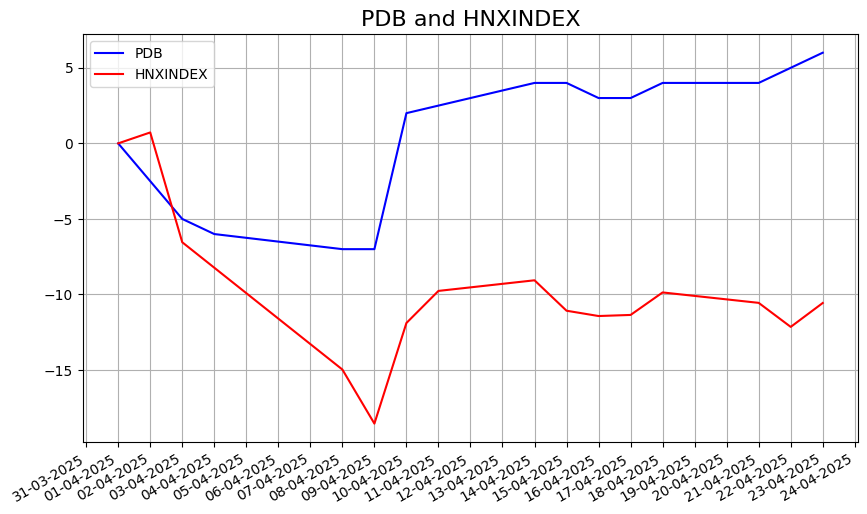

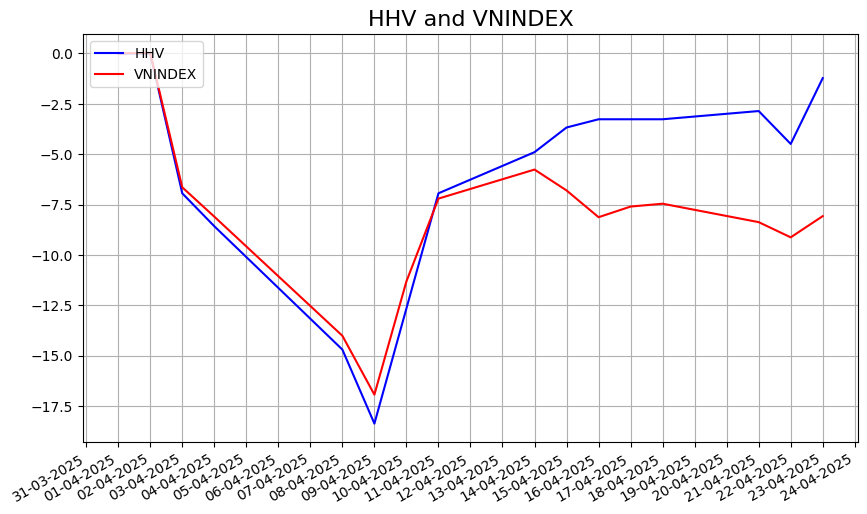

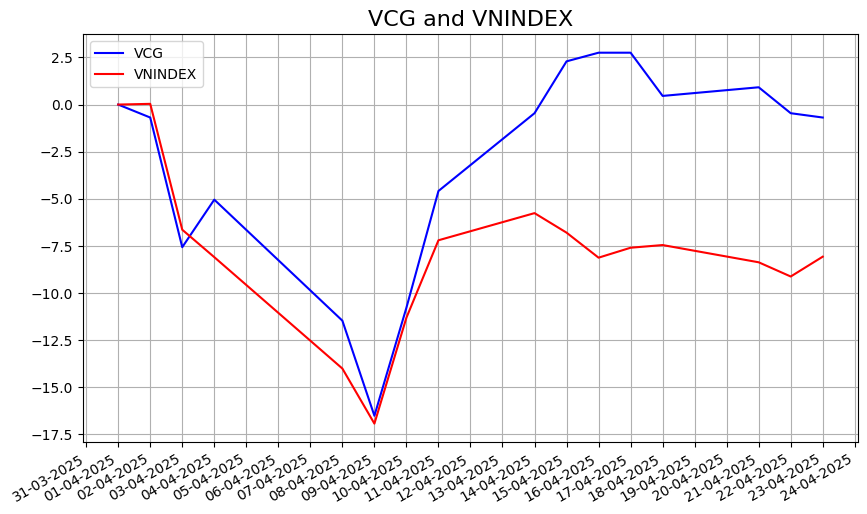

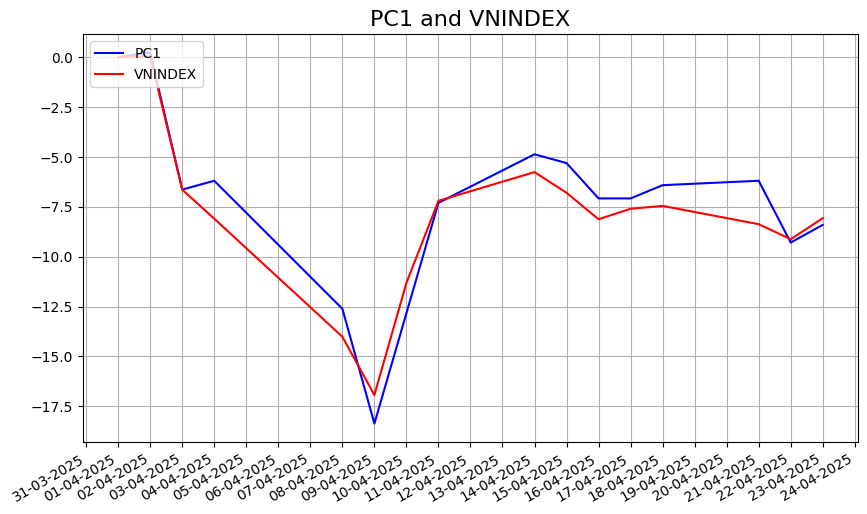

In [85]:
potential_stock_list = ['FCN', 'PDB', 'HHV', 'VCG', 'PC1']
for symbol in potential_stock_list:
    if symbol == 'PDB':
        show_plt(hnx, symbol, hnxindex, "HNXINDEX")
    elif symbol == 'PC1':
        show_plt(pc1, symbol, vnindex, "VNINDEX")
    else:
        show_plt(hsx, symbol, vnindex, "VNINDEX")
        